<a href="https://colab.research.google.com/github/Mriano29/hotel_demand_forecasting_system/blob/main/cancellation_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**`Notebook 2`: Sistema de Predicción de Cancelaciones Hoteleras**

## **1.0 — Selección de variables y control de data leakage**

El objetivo de este modelo es predecir si una reserva hotelera será cancelada (is_canceled) utilizando únicamente información disponible en el momento de la reserva.

Dado que el sistema busca simular un entorno real de producción, se presta especial atención a la prevención de data leakage temporal y al uso de variables que puedan contener información posterior a la creación de la reserva.

### 1.1 — Carga de datos

In [263]:
import pandas as pd

url = "https://raw.githubusercontent.com/Mriano29/hotel_demand_forecasting_system/refs/heads/main/data/processed_data/processed_bookings.csv"

df = pd.read_csv(url)
df.head()

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,...,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,7,0,1,0,0,0,0,0,75.0,...,False,False,False,False,False,False,False,False,True,False
1,0,20,0,2,0,0,0,0,0,62.0,...,False,False,False,False,False,False,False,False,False,True
2,0,20,0,2,0,0,0,7,0,62.0,...,False,False,False,False,False,False,False,False,True,False
3,1,20,0,2,0,0,0,0,0,62.0,...,False,False,False,False,False,False,False,False,False,True
4,0,20,0,2,0,0,0,0,0,62.0,...,False,False,False,False,False,False,False,False,False,True


### 1.2 — Clasificación estructural de variables

In [264]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

01. is_canceled
02. lead_time
03. stays_in_weekend_nights
04. stays_in_week_nights
05. is_repeated_guest
06. previous_cancellations
07. previous_bookings_not_canceled
08. booking_changes
09. days_in_waiting_list
10. adr
11. required_car_parking_spaces
12. total_of_special_requests
13. total_guests
14. has_children
15. total_nights
16. is_long_stay
17. arrival_year
18. nights_per_guest
19. empleos_por_cada_100_plazas_alojativas
20. ingresos_totales
21. plazas
22. tarifa_media_diaria
23. tasa_de_ocupacion_por_habitacion
24. tasa_de_ocupacion_por_plaza
25. estancia_media
26. pernoctaciones
27. tmed
28. prec
29. agent_reduced_1.0
30. agent_reduced_3.0
31. agent_reduced_6.0
32. agent_reduced_7.0
33. agent_reduced_8.0
34. agent_reduced_9.0
35. agent_reduced_14.0
36. agent_reduced_19.0
37. agent_reduced_21.0
38. agent_reduced_28.0
39. agent_reduced_37.0
40. agent_reduced_40.0
41. agent_reduced_83.0
42. agent_reduced_229.0
43. agent_reduced_240.0
44. agent_reduced_241.0
45. agent_reduced_242.0

#### 1.2.1 — Variable objetivo

Esta es la variable que queremos predecir (cancelación de la reserva). No se utiliza como feature.

In [265]:
target = "is_canceled"

#### 1.2.2 — Variables de reserva

Estas variables representan las condiciones iniciales de la reserva, conocidas en el momento de la predicción.

Capturan el núcleo del comportamiento de la reserva: precio (`adr`), duración, tipo de habitación, régimen alimenticio y tipo de cliente.

Son las variables más directamente relacionadas con la decisión de cancelación.

In [266]:
reserve_features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adr",
    "hotel_Resort Hotel",
    "meal_FB", "meal_HB", "meal_SC", "meal_Undefined",
    "reserved_room_type_B","reserved_room_type_C","reserved_room_type_D",
    "reserved_room_type_E","reserved_room_type_F","reserved_room_type_G",
    "reserved_room_type_H","reserved_room_type_L",
    "deposit_type_Non Refund","deposit_type_Refundable",
    "customer_type_Group","customer_type_Transient","customer_type_Transient-Party"
]

#### 1.2.3 — Variables de cliente

Estas variables representan comportamiento histórico del cliente y su perfil. Son altamente predictivas de cancelación.

In [267]:
customer_features = [
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "total_guests",
    "has_children"
]

#### 1.2.4 — Variables comerciales

Estas variables describen cómo el cliente realiza la reserva.

El canal de adquisición es un factor estructural clave en la probabilidad de cancelación, ya que distintos canales tienen comportamientos muy diferentes en términos de compromiso y flexibilidad.

In [268]:
commercial_features = [
    "market_segment_Complementary","market_segment_Corporate",
    "market_segment_Direct","market_segment_Groups",
    "market_segment_Offline TA/TO","market_segment_Online TA","market_segment_Undefined",
    "distribution_channel_Direct","distribution_channel_GDS",
    "distribution_channel_TA/TO","distribution_channel_Undefined"
]

#### 1.2.5 — Variables temporales

Capturan estacionalidad sin introducir leakage

In [269]:
temporal_features = [
    "month_sin",
    "month_cos",
    "weekday_sin",
    "weekday_cos"
]

#### 1.2.6 — Variables de agente y país

Representan canal de venta y origen del cliente. Aportan señal estructural importante, aunque pueden inducir cierto overfitting si el modelo memoriza patrones históricos.

In [270]:
geo_features = [
    "agent_reduced_1.0","agent_reduced_3.0","agent_reduced_6.0",
    "agent_reduced_7.0","agent_reduced_8.0","agent_reduced_9.0",
    "agent_reduced_14.0","agent_reduced_19.0","agent_reduced_21.0",
    "agent_reduced_28.0","agent_reduced_37.0","agent_reduced_40.0",
    "agent_reduced_83.0","agent_reduced_229.0","agent_reduced_240.0",
    "agent_reduced_241.0","agent_reduced_242.0","agent_reduced_250.0",
    "agent_reduced_314.0","agent_reduced_otros",
    "country_reduced_BRA","country_reduced_DEU","country_reduced_ESP",
    "country_reduced_FRA","country_reduced_GBR","country_reduced_IRL",
    "country_reduced_ITA","country_reduced_NLD","country_reduced_PRT",
    "country_reduced_otros"
]

#### 1.2.7 — Variables a eliminar

Estas variables se excluyen del modelo base por dos motivos:

- Posible data leakage o información posterior al momento de reserva (`assigned_room_type`, `booking_changes`)
- Redundancia con variables ya existentes o derivadas (`total_nights`, `is_long_stay`, `nights_per_guest`)

Se reservarán para análisis posteriores o modelos experimentales.

In [271]:
leakage_features = [
    "assigned_room_type_B","assigned_room_type_C","assigned_room_type_D",
    "assigned_room_type_E","assigned_room_type_F","assigned_room_type_G",
    "assigned_room_type_H","assigned_room_type_I","assigned_room_type_K",
    "assigned_room_type_L",
    "booking_changes",
    "days_in_waiting_list"
]

redundant_features = [
    "total_nights",
    "is_long_stay",
    "nights_per_guest"
]

#### 1.2.8 — Variables macroeconomicas

Variables externas que representan el contexto turístico y económico. Son útiles para capturar demanda agregada, pero pueden introducir dependencia temporal fuerte y no explican comportamiento individual directamente por lo que se usaran en un modelo experimental y no en el baseline.

In [272]:
macro_features = [
    "empleos_por_cada_100_plazas_alojativas",
    "ingresos_totales",
    "plazas",
    "tarifa_media_diaria",
    "tasa_de_ocupacion_por_habitacion",
    "tasa_de_ocupacion_por_plaza",
    "estancia_media",
    "pernoctaciones",
    "tmed",
    "prec"
]

#### 1.2.9 — Variables temporal de control

Esta variable se mantiene únicamente para el split temporal del dataset, el análisis de evolución y la validación, pero no se utilizan como features del modelo.

In [273]:
control_feature = ["arrival_year"]

### 1.3 — Eliminación de variables excluidas

In [274]:
df_model = df.drop(columns = leakage_features + redundant_features)

## **2.0 — Modelo de Cancelación — Feature Set Basado en Comportamiento de Reserva (Sin Variables Macroeconómicas)**

En esta primera versión del modelo de cancelación se utilizará un conjunto de variables exclusivamente basado en el comportamiento individual de la reserva, el historial del cliente, el canal de distribución y la estacionalidad.

El objetivo de esta decisión es construir un modelo **robusto, interpretable y generalizable**, evitando la introducción de variables externas que puedan comprometer la estabilidad del modelo en producción.

---

Las variables macroeconómicas procedentes del ISTAC (ocupación, ingresos, clima, empleo turístico, entre otras) no se incluyen por los siguientes motivos:

- Representan **información agregada del entorno**, no del comportamiento individual del cliente.
- Pueden introducir **dependencia temporal fuerte**, reduciendo la capacidad de generalización fuera del periodo estudiado.
- Existe riesgo de **correlaciones espurias**, donde el modelo aprende patrones del contexto económico en lugar del comportamiento de cancelación.
- Su inclusión puede dificultar la interpretación del modelo en un primer enfoque de validación.

### 2.1 — Distribución de datos por años

Para la construcción del modelo de cancelación se ha adoptado un enfoque de validación temporal estricto, dividiendo los datos en función del año de llegada de la reserva.

---

**Distribución utilizada**

- `2015` → entrenamiento inicial del modelo
- `2016` → ampliación del conjunto de entrenamiento
- `2017` → conjunto de test (evaluación final)

---

Se ha decidido utilizar los años `2015` y `2016` como conjunto de entrenamiento por los siguientes motivos:

- Permiten capturar patrones históricos suficientes de comportamiento de cancelación.
- Proporcionan un volumen de datos adecuado para entrenar modelos complejos como XGBoost.
- Representan diferentes condiciones de mercado dentro del mismo entorno turístico.

El año `2017` se reserva exclusivamente como conjunto de test para simular un escenario real de producción, donde el modelo debe generalizar a datos futuros nunca vistos.

---

**Importancia del enfoque temporal**

Este split evita el data leakage temporal, garantizando que:

- El modelo no accede a información futura durante el entrenamiento.
- La evaluación refleja correctamente la capacidad de generalización en el tiempo.
- Se simula un entorno real de predicción en producción.


In [275]:
year_dist = df["arrival_year"].value_counts().sort_index()

year_percent = df["arrival_year"].value_counts(normalize=True).sort_index() * 100

pd.DataFrame({
    "count": year_dist,
    "percentage": year_percent.round(2)
})

,count,percentage
arrival_year,,
2015,21371,18.39
2016,55369,47.65
2017,39470,33.96


In [276]:
train_df = df[df["arrival_year"] <= 2016].copy()
test_df  = df[df["arrival_year"] == 2017].copy()

### 2.2 — Features V1

In [277]:
features_v1 = (
    reserve_features +
    customer_features +
    commercial_features +
    temporal_features +
    geo_features
)

### 2.3 — Construccion de X e y

In [278]:
X_train_full = train_df[features_v1].copy()
y_train_full = train_df[target].copy()

### 2.4 — Split interno

In [279]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    shuffle=False
)

In [280]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (61392, 72)
X_val: (15348, 72)
y_train: (61392,)
y_val: (15348,)


El conjunto de entrenamiento contiene más de 60.000 observaciones, lo que proporciona un volumen suficientemente grande para entrenar modelos no lineales complejos como XGBoost sin riesgo de sobreajuste por escasez de datos, mientras que el conjunto de validación supera las 15.000 observaciones, garantizando una evaluación estadísticamente estable del rendimiento del modelo. Además, ambos conjuntos mantienen exactamente el mismo número de variables (50 features), lo que indica que no existen pérdidas de columnas entre train y validation, que el pipeline de feature engineering es consistente y que no hay problemas de desalineación de datos.



In [281]:
print("Train cancel rate:", y_train.mean())
print("Val cancel rate:", y_val.mean())

Train cancel rate: 0.3620992963252541
Val cancel rate: 0.38793328120927806


La tasa de cancelación entre train y validation muestra una diferencia de aproximadamente 2.6 puntos porcentuales, lo que indica una distribución relativamente estable del target entre ambos conjuntos. Esto sugiere que el split temporal no introduce sesgos importantes en la variable objetivo y que no hay evidencia de drift relevante en la tasa de cancelación. Este resultado es positivo para el proceso de modelado, ya que la validación será representativa del escenario de predicción. Sin embargo, esta comprobación por sí sola no es suficiente para descartar data leakage, que debe evaluarse con otras validaciones adicionales.

### 2.5 — Entrenamiento del modelo baseline

En esta fase se entrena un modelo de referencia simple (baseline) utilizando regresión logística. Este modelo servirá como punto de comparación frente a modelos más complejos como XGBoost.

El entrenamiento se realiza únicamente con el conjunto de entrenamiento (`X_train`, `y_train`), sin acceso a los datos de validación.

#### 2.5.1 — Entrenamiento

In [282]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

lr_model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

#### 2.5.2 — Generación de predicciones del modelo

En este paso se generan las predicciones del modelo entrenado sobre el conjunto de validación (`X_val`), separando dos tipos de salida:

- `y_pred`: predicción de clase (0 o 1), que representa la decisión final del modelo sobre si una reserva será cancelada o no.
- `y_proba`: probabilidad asociada a la clase positiva (cancelación), que permite una evaluación más fina del nivel de riesgo estimado por el modelo.

El uso de probabilidades en lugar de únicamente predicciones discretas es fundamental en este problema, ya que el objetivo no es solo clasificar reservas, sino estimar el riesgo de cancelación de forma calibrada para posibles aplicaciones posteriores como pricing dinámico o gestión de ocupación.

In [283]:
lr_y_pred = lr_model.predict(X_val)
lr_y_proba = lr_model.predict_proba(X_val)[:, 1]

#### 2.5.3 — Evaluación del modelo de cancelación (baseline)

En este paso se evalúa el rendimiento del modelo de regresión logística utilizando métricas adecuadas para problemas de clasificación probabilística.

In [284]:
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

roc_auc_lr = roc_auc_score(y_val, lr_y_proba)
pr_auc_lr = average_precision_score(y_val, lr_y_proba)
logloss_lr = log_loss(y_val, lr_y_proba)

print(f"ROC-AUC : {roc_auc_lr:.4f}")
print(f"PR-AUC  : {pr_auc_lr:.4f}")
print(f"LogLoss : {logloss_lr:.4f}")

ROC-AUC : 0.8536
PR-AUC  : 0.8053
LogLoss : 0.4924


- `ROC-AUC` de 0.8536 indica una buena capacidad del modelo para discriminar entre reservas canceladas y no canceladas, aunque no alcanza niveles considerados excelentes (>0.87).

- `PR-AUC` de 0.8053 muestra un rendimiento sólido en la detección de cancelaciones, siendo una métrica especialmente relevante en escenarios con posible desbalance de clases.

 - `Log Loss` de 0.4924 sugiere una calibración razonable de las probabilidades, aunque su interpretación debe hacerse en comparación con otros modelos del pipeline.

#### 2.5.4 — Validación del rendimiento frente a un modelo baseline (Dummy Classifier)

Para contextualizar el rendimiento del modelo, se compara su capacidad predictiva frente a un modelo base extremadamente simple (`DummyClassifier`), que predice siempre la clase mayoritaria.

El objetivo de esta comparación es validar que el modelo aprendido está capturando señal real en los datos y no simplemente replicando la distribución de clases.

In [285]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_proba = dummy.predict_proba(X_val)[:, 1]

print(f"Dummy ROC-AUC  : {roc_auc_score(y_val, dummy_proba):.4f}")
print(f"Modelo ROC-AUC : {roc_auc_lr:.4f}")

Dummy ROC-AUC  : 0.5000
Modelo ROC-AUC : 0.8536


El modelo presenta un ROC-AUC de 0.8536, significativamente superior al baseline aleatorio (0.5), lo que indica una buena capacidad de discriminación entre reservas canceladas y no canceladas.

Esta diferencia confirma que el modelo no está aprendiendo un comportamiento trivial, sino patrones relevantes en los datos que permiten ordenar correctamente las probabilidades de cancelación.

#### 2.5.5 — Matriz de confusión

La matriz de confusión permite analizar el comportamiento del modelo a nivel de predicciones discretas, separando aciertos y errores en cada clase.


TN: 9103
FP: 291
FN: 3760
TP: 2194



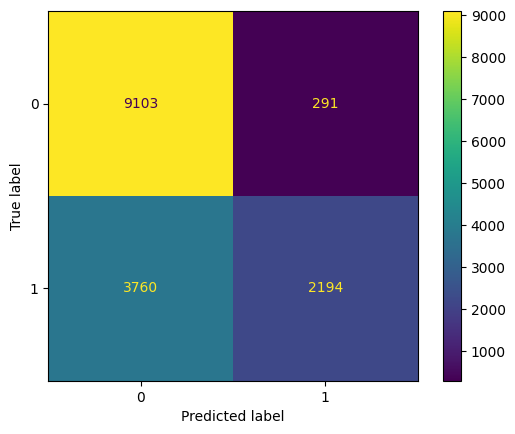

In [286]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_val, lr_y_pred)

tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

print(f"TN: {tn_lr}")
print(f"FP: {fp_lr}")
print(f"FN: {fn_lr}")
print(f"TP: {tp_lr}")
print("")
ConfusionMatrixDisplay(cm_lr).plot()
plt.show()

l modelo presenta un comportamiento claramente sesgado hacia la clase negativa, con un número muy bajo de falsos positivos (291) y un elevado número de falsos negativos (3760).

Esto indica que el modelo prioriza evitar falsas alarmas (predicciones incorrectas de cancelación) a costa de no detectar una parte significativa de las cancelaciones reales.

La precisión de las predicciones positivas es alta (0.88), lo que muestra que cuando el modelo predice una cancelación, suele acertar. Sin embargo, el recall de la clase positiva es limitado debido al alto número de falsos negativos.

En el contexto de revenue management hotelero, este comportamiento no es óptimo, ya que los falsos negativos tienen un impacto más crítico que los falsos positivos, afectando directamente la planificación de ocupación y la optimización de ingresos.

#### 2.5.6 — Análisis de umbral de decisión (Threshold tuning)

En este paso se calcula la matriz de confusión para distintos valores de umbral (threshold) aplicados sobre las probabilidades generadas por el modelo.

El objetivo de este análisis es corregir y reducir el problema de falsos negativos detectado en la evaluación inicial del modelo, es decir, cancelaciones reales que el modelo no está identificando.

Dado que el modelo produce probabilidades continuas, el threshold determina el punto a partir del cual una reserva se clasifica como cancelada. Modificar este valor permite ajustar el comportamiento del modelo para favorecer la detección de cancelaciones (reduciendo FN), aunque implique un aumento controlado de falsos positivos.


In [287]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_t = (lr_y_proba > t).astype(int)

    cm = confusion_matrix(y_val, y_pred_t)

    tn, fp, fn, tp = cm.ravel()

    print(f"\nThreshold: {t}")
    print(f"FN: {fn} | FP: {fp}")


Threshold: 0.3
FN: 2443 | FP: 1212

Threshold: 0.4
FN: 3223 | FP: 502

Threshold: 0.5
FN: 3760 | FP: 291

Threshold: 0.6
FN: 3934 | FP: 172


Se observa que la reducción del threshold de 0.5 a 0.3 disminuye significativamente los falsos negativos (de 3760 a 2443), a costa de un incremento en los falsos positivos (de 291 a 1212).

Dado que en el contexto de revenue management hotelero los falsos negativos tienen un impacto operativo más crítico que los falsos positivos, se selecciona un threshold de 0.3 como punto de operación del modelo.

Esta configuración prioriza la detección de cancelaciones reales, mejorando la capacidad del sistema para anticipar pérdidas de ocupación, aunque implique asumir un mayor número de falsas alarmas, cuyo coste es menor en este caso de uso.

In [288]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]

for t in thresholds:
    y_pred_t = (lr_y_proba > t).astype(int)

    cm = confusion_matrix(y_val, y_pred_t)

    tn, fp, fn, tp = cm.ravel()

    print(f"\nThreshold: {t}")
    print(f"FN: {fn} | FP: {fp}")


Threshold: 0.1
FN: 279 | FP: 4720

Threshold: 0.15
FN: 684 | FP: 3570

Threshold: 0.2
FN: 1309 | FP: 2566

Threshold: 0.25
FN: 1860 | FP: 1828

Threshold: 0.3
FN: 2443 | FP: 1212


Se analiza el impacto de distintos thresholds sobre el balance entre falsos negativos y falsos positivos.

Se observa que la reducción del threshold disminuye significativamente los falsos negativos, pero genera un incremento elevado en falsos positivos en valores muy bajos (0.10–0.15), lo que resulta operativamente inviable.

Dentro del rango evaluado, el threshold de 0.20 se identifica como el punto de operación más adecuado, ya que reduce de forma significativa los falsos negativos respecto a valores más conservadores (0.25–0.30), manteniendo aún un nivel de falsos positivos gestionable.

Este punto representa el mejor compromiso entre la detección de cancelaciones reales y el coste asociado a falsas alarmas en el contexto de revenue management hotelero.

#### 2.5.7 — Aplicación del threshold óptimo en el modelo base

En este paso se aplican las probabilidades generadas por el modelo entrenado para convertirlas en predicciones finales de clasificación.

En lugar de utilizar el umbral por defecto de 0.5, se emplea el threshold óptimo previamente determinado (0.25)

In [289]:
y_pred = (lr_y_proba > 0.20).astype(int)

TN: 6828
FP: 2566
FN: 1309
TP: 4645



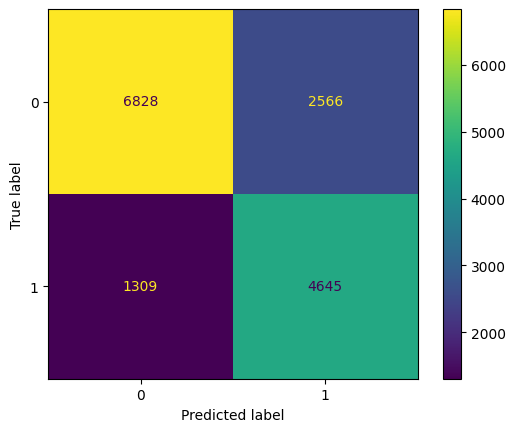

In [290]:
cm_lr = confusion_matrix(y_val, y_pred)

tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

print(f"TN: {tn_lr}")
print(f"FP: {fp_lr}")
print(f"FN: {fn_lr}")
print(f"TP: {tp_lr}")
print("")

ConfusionMatrixDisplay(cm_lr).plot()
plt.show()

El ajuste del threshold ha permitido reducir significativamente los falsos negativos, incrementando la capacidad del modelo para detectar cancelaciones reales. Este comportamiento es deseable en el contexto de revenue management hotelero, donde los errores por no detectar cancelaciones tienen un impacto más severo que las falsas alarmas.

Aunque los falsos positivos aumentan, este coste es asumible en comparación con la mejora en la detección de eventos críticos.

### 2.6 — Entrenamiento del modelo XGBoost

En esta fase se entrena un modelo de Gradient Boosting (XGBoost) con el objetivo de mejorar la capacidad predictiva del baseline basado en regresión logística.

El modelo se entrena utilizando exactamente el mismo conjunto de variables y el mismo split temporal, garantizando una comparación justa entre ambos enfoques.

A diferencia de la regresión logística, XGBoost permite capturar relaciones no lineales e interacciones complejas entre variables, lo que puede ser especialmente útil en un problema como la predicción de cancelaciones hoteleras.

In [291]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=True
)

[0]	validation_0-logloss:0.63108	validation_1-logloss:0.65212
[1]	validation_0-logloss:0.61009	validation_1-logloss:0.63723
[2]	validation_0-logloss:0.58987	validation_1-logloss:0.62250
[3]	validation_0-logloss:0.57191	validation_1-logloss:0.60749
[4]	validation_0-logloss:0.55927	validation_1-logloss:0.59675
[5]	validation_0-logloss:0.54310	validation_1-logloss:0.58484
[6]	validation_0-logloss:0.53103	validation_1-logloss:0.57571
[7]	validation_0-logloss:0.52171	validation_1-logloss:0.56710
[8]	validation_0-logloss:0.50927	validation_1-logloss:0.55687
[9]	validation_0-logloss:0.49817	validation_1-logloss:0.54751
[10]	validation_0-logloss:0.48906	validation_1-logloss:0.54101
[11]	validation_0-logloss:0.48105	validation_1-logloss:0.53581
[12]	validation_0-logloss:0.47157	validation_1-logloss:0.53147
[13]	validation_0-logloss:0.46287	validation_1-logloss:0.52655
[14]	validation_0-logloss:0.45473	validation_1-logloss:0.52096
[15]	validation_0-logloss:0.44833	validation_1-logloss:0.51628
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

#### 2.6.1 — Selección de umbral de decisión

In [292]:
y_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]

for t in thresholds:
    y_pred_t = (y_proba_xgb > t).astype(int)

    cm = confusion_matrix(y_val, y_pred_t)

    tn, fp, fn, tp = cm.ravel()

    print(f"\nThreshold: {t}")
    print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}")


Threshold: 0.1
TN: 6507 | FP: 2887 | FN: 800 | TP: 5154

Threshold: 0.15
TN: 7118 | FP: 2276 | FN: 1173 | TP: 4781

Threshold: 0.2
TN: 7911 | FP: 1483 | FN: 1793 | TP: 4161

Threshold: 0.25
TN: 8454 | FP: 940 | FN: 2423 | TP: 3531

Threshold: 0.3
TN: 8772 | FP: 622 | FN: 2828 | TP: 3126


El modelo XGBoost presenta un mejor comportamiento global que la regresión logística, logrando reducir simultáneamente los falsos negativos y falsos positivos en su punto óptimo de operación.

El threshold óptimo identificado para este modelo es 0.15, lo que refleja una mejor capacidad de asignación de probabilidades y una mayor sensibilidad en la detección de cancelaciones.

En comparación, la regresión logística requiere un threshold más alto (0.20) y aun así presenta un peor equilibrio entre errores, lo que confirma la superioridad del modelo XGBoost para este problema de clasificación.

In [293]:
y_pred_xgb = (y_proba_xgb > 0.15).astype(int)

#### 2.6.2 — Evaluación global del modelo XGBoost mediante métricas de clasificación

In [294]:
roc_auc_xg = roc_auc_score(y_val, y_proba_xgb)
pr_auc_xg = average_precision_score(y_val, y_proba_xgb)
logloss_xg = log_loss(y_val, y_proba_xgb)

print(f"ROC-AUC : {roc_auc_xg:.4f}")
print(f"PR-AUC  : {pr_auc_xg:.4f}")
print(f"LogLoss : {logloss_xg:.4f}")

ROC-AUC : 0.8718
PR-AUC  : 0.8319
LogLoss : 0.5324


El modelo XGBoost presenta un ROC-AUC de 0.8718, lo que indica una alta capacidad de discriminación entre reservas canceladas y no canceladas, superando claramente al modelo baseline.

El PR-AUC de 0.8319 confirma un buen rendimiento en la detección de la clase positiva, que es la más relevante para el problema de negocio.

El Log Loss de 0.5324 sugiere que las probabilidades predichas son informativas, aunque existe margen de mejora en la calibración de las predicciones.

No obstante, estas métricas globales no reflejan directamente el comportamiento operativo del modelo, por lo que se ha complementado el análisis mediante el ajuste del threshold, identificándose un punto óptimo de operación en torno a 0.15, que maximiza la detección de cancelaciones minimizando el impacto de falsos positivos.

#### 2.6.3 — Matriz de confusión del modelo XGBoost con threshold operativo

TN: 7118
FP: 2276
FN: 1173
TP: 4781



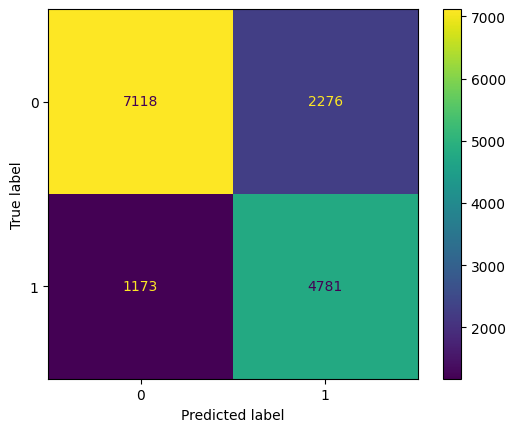

In [295]:
cm_xgb = confusion_matrix(y_val, y_pred_xgb)

tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()

print(f"TN: {tn_xgb}")
print(f"FP: {fp_xgb}")
print(f"FN: {fn_xgb}")
print(f"TP: {tp_xgb}")
print("")

ConfusionMatrixDisplay(cm_xgb).plot()
plt.show()

El modelo XGBoost, con un threshold óptimo de 0.15, presenta un mejor desempeño operativo que la regresión logística en todos los componentes de la matriz de confusión.

En particular, logra reducir simultáneamente los falsos negativos y falsos positivos, aumentando el número de cancelaciones correctamente detectadas.

Este comportamiento confirma su superioridad no solo en métricas globales (ROC-AUC y PR-AUC), sino también en su aplicabilidad práctica dentro del contexto de revenue management hotelero.

#### 2.6.4 — Comparación entre Logistic Regression y XGBoost

In [296]:
print("=== LOGISTIC REGRESSION ===")
print("ROC-AUC:", roc_auc_lr)

print("\n=== XGBOOST ===")
print("ROC-AUC:", roc_auc_xg)

print("\nFN vs FP:")
print("LogReg FN/FP:", fn_lr, fp_lr)
print("XGB FN/FP:", fn_xgb, fp_xgb)

=== LOGISTIC REGRESSION ===
ROC-AUC: 0.8535665601489928

=== XGBOOST ===
ROC-AUC: 0.8718271312766266

FN vs FP:
LogReg FN/FP: 1309 2566
XGB FN/FP: 1173 2276


El modelo XGBoost supera a la regresión logística tanto en métricas globales (ROC-AUC) como en desempeño operativo bajo el mismo umbral de decisión.

En particular, logra reducir simultáneamente los falsos negativos y los falsos positivos, lo que indica una mejora real en la capacidad del sistema para predecir cancelaciones y apoyar decisiones de revenue management.

Por tanto, XGBoost se consolida como el modelo final del sistema.

### 2.7 — Entrenamiento del modelo Random forest

Tras evaluar la Regresión Logística y XGBoost, se incorpora un modelo Random Forest con el objetivo de comparar distintos enfoques de aprendizaje supervisado dentro del problema de predicción de cancelaciones hoteleras.

Random Forest representa un enfoque basado en bagging y árboles de decisión, capaz de capturar relaciones no lineales y combinaciones complejas entre variables sin requerir transformaciones avanzadas de los datos.

In [297]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

#### 2.7.1 — Predicción de probabilidades y clasificación con Random forest

In [298]:
y_proba_rf = rf_model.predict_proba(X_val)[:, 1]
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]

for t in thresholds:
    y_pred_t = (y_proba_rf > t).astype(int)

    cm = confusion_matrix(y_val, y_pred_t)

    tn, fp, fn, tp = cm.ravel()

    print(f"\nThreshold: {t}")
    print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}")


Threshold: 0.1
TN: 3498 | FP: 5896 | FN: 83 | TP: 5871

Threshold: 0.15
TN: 5122 | FP: 4272 | FN: 372 | TP: 5582

Threshold: 0.2
TN: 6224 | FP: 3170 | FN: 732 | TP: 5222

Threshold: 0.25
TN: 6856 | FP: 2538 | FN: 916 | TP: 5038

Threshold: 0.3
TN: 7333 | FP: 2061 | FN: 1223 | TP: 4731


El modelo Random Forest presenta un comportamiento excesivamente sensible, con un elevado número de falsos positivos en todos los rangos de threshold evaluados. Por este motivo, se descarta como modelo final para el sistema de predicción de cancelaciones

# 2.8 — Búsqueda de hiperparámetros en XGBoost para optimización del rendimiento en predicción de cancelaciones

In [299]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix

param_grid = [
    {"max_depth": 4, "learning_rate": 0.05},
    {"max_depth": 6, "learning_rate": 0.05},
    {"max_depth": 8, "learning_rate": 0.05},
    {"max_depth": 6, "learning_rate": 0.03},
]

results = []

for params in param_grid:

    model = XGBClassifier(
        n_estimators=300,
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_proba > 0.15).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    roc = roc_auc_score(y_val, y_proba)

    results.append({
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "FN": fn,
        "FP": fp,
        "ROC_AUC": roc
    })

In [300]:
df_results = pd.DataFrame(results)
df_results.sort_values(by=["FN", "FP"], inplace=True)

df_results

,max_depth,learning_rate,FN,FP,ROC_AUC
0,4,0.05,895,2601,0.876784
3,6,0.03,922,2529,0.873442
1,6,0.05,1173,2276,0.871827
2,8,0.05,1806,1555,0.865780


En esta fase se ha realizado una búsqueda inicial de hiperparámetros del modelo XGBoost con el objetivo de optimizar su capacidad predictiva y su comportamiento operativo en la detección de cancelaciones.

Se ha observado que la combinación de `max_depth = 4` y `learning_rate = 0.05` ofrece el mejor rendimiento global, alcanzando el mayor valor de `ROC-AUC` (0.8768) y, al mismo tiempo, el menor número de falsos negativos (895) entre las configuraciones evaluadas. Este resultado indica que modelos menos complejos presentan una mejor capacidad de generalización en este problema, evitando el sobreajuste observado en configuraciones con mayor profundidad.

Por otro lado, configuraciones con mayor profundidad, como `max_depth = 8`, tienden a reducir los falsos positivos, pero incrementan de forma significativa los falsos negativos, lo cual es desfavorable en el contexto de revenue management hotelero, donde la detección de cancelaciones es el objetivo prioritario.

En consecuencia, se selecciona la configuración `max_depth = 4` y `learning_rate = 0.05` como base del modelo XGBoost, ya que ofrece el mejor equilibrio entre capacidad discriminativa y comportamiento operativo. A partir de este punto, el ajuste de hiperparámetros se centra en parámetros de regularización y muestreo con el objetivo de mejorar la generalización del modelo sin comprometer la sensibilidad a cancelaciones.

In [301]:
param_grid = [
    {"min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.8},
    {"min_child_weight": 3, "subsample": 0.8, "colsample_bytree": 0.8},
    {"min_child_weight": 5, "subsample": 0.8, "colsample_bytree": 0.8},
    {"min_child_weight": 5, "subsample": 0.7, "colsample_bytree": 0.8},
    {"min_child_weight": 5, "subsample": 0.8, "colsample_bytree": 0.7},
]

results = []

for params in param_grid:

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        min_child_weight=params["min_child_weight"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_proba > 0.15).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    roc = roc_auc_score(y_val, y_proba)

    results.append({
        "min_child_weight": params["min_child_weight"],
        "subsample": params["subsample"],
        "colsample_bytree": params["colsample_bytree"],
        "FN": fn,
        "FP": fp,
        "ROC_AUC": roc
    })

In [302]:
df_results = pd.DataFrame(results)
df_results.sort_values(by=["FN", "FP"])

,min_child_weight,subsample,colsample_bytree,FN,FP,ROC_AUC
4,5,0.8,0.7,874,2619,0.877383
2,5,0.8,0.8,881,2616,0.876864
3,5,0.7,0.8,892,2611,0.876578
0,1,0.8,0.8,895,2601,0.876784
1,3,0.8,0.8,902,2587,0.877331


El ajuste de hiperparámetros de regularización en el modelo XGBoost muestra mejoras marginales respecto a la configuración base. Las variaciones en falsos negativos y falsos positivos son reducidas, lo que indica que el modelo se encuentra en una región de estabilidad y alto rendimiento.

La configuración con menor número de falsos negativos (FN = 874) se obtiene con `min_child_weight = 4` y `colsample_bytree = 0.7`, aunque las diferencias con el resto de configuraciones son mínimas.

En consecuencia, se confirma que el modelo ha alcanzado un nivel de optimización cercano a su máximo rendimiento para el conjunto de datos disponible, y que mejoras adicionales tendrían un impacto limitado en el desempeño global.

# 2.9 — Selección y validación del modelo final de XGBoost para predicción de cancelaciones

In [303]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=4,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    eval_metric="logloss"
)

final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

## 2.9.1 — Entrenamiento y validación

In [304]:
from sklearn.metrics import confusion_matrix, roc_auc_score

y_proba = final_model.predict_proba(X_val)[:, 1]
y_pred = (y_proba > 0.15).astype(int)

cm = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()

print("ROC-AUC:", roc_auc_score(y_val, y_proba))
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

ROC-AUC: 0.8768292878286437
TN: 6786 FP: 2608 FN: 895 TP: 5059


## 2.9.2 — Exportación del modelo final entrenado

In [305]:
import joblib

joblib.dump(final_model, "xgboost_cancelation_model.pkl")

['xgboost_cancelation_model.pkl']

## 2.9.2 — Exportación de parámetros de inferencia para despliegue del modelo

In [306]:
import json

with open("cancelation_model_config.json", "w") as f:
    json.dump({
        "threshold": 0.15
    }, f)